In [2]:
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
books_df = pd.read_csv('./clean_merge/books.csv', low_memory=False)
ratings_df = pd.read_csv('./clean_merge/ratings.csv',low_memory=False)
books_genres_df = pd.read_csv('./clean_merge/book_genres.csv',low_memory=False)
users_df = pd.read_csv('./clean_merge/users.csv',low_memory=False)

In [18]:
books_df

,id,title,crawl_source,ISBN_10,description,image_url,author,language,publish_date,num_pages
0,9780578406053,The Beauty Of The Mass: Exploring The Central ...,hardcover,0578406055,An in-depth dive through every aspect of the H...,https://assets.hardcover.app/edition/31306658/...,Charles S. Johnston,English,2018-11-12,0.0
1,9781438407166,"Collaborative Construction of Pretend, The",hardcover,1438407165,The Collaborative Construction of Pretend expl...,https://assets.hardcover.app/external_data/601...,Carollee Howes,English,1992-01-01,172.0
2,9780751503890,The Physician,goodreads,0751503894,"In the 11th century, Rob Cole left poor, disea...",https://images-na.ssl-images-amazon.com/images...,Noah Gordon,English,2001-07-01,714.0
3,9783834915528,Operationalisierung einer Nachhaltigkeitsstrat...,hardcover,3834915521,Alexandro Kleine entwickelt ein Operationalisi...,https://assets.hardcover.app/external_data/601...,Alexandro Kleine,English,2009-02-26,232.0
4,9782226109552,Lorsque j'étais une œuvre d'art,hardcover,2226109552,Lorsque j'étais une œuvre d'art est un livre s...,https://assets.hardcover.app/external_data/599...,Éric-Emmanuel Schmitt,English,2002-01-01,294.0
...,...,...,...,...,...,...,...,...,...,...
284918,9780316365819,"The Witches: Salem, 1692",hardcover,0316200603,The Pulitzer Prize-winning author of Cleopatra...,https://assets.hardcover.app/external_data/266...,Stacy Schiff,English,2015-01-01,498.0
284919,9788741859552,Det brændte barn,hardcover,NaN,NaN,https://assets.hardcover.app/external_data/603...,Ursula K. Le Guin,English,1990-06-20,238.0
284920,9781508706250,The Deal,hardcover,1508706255,Hannah Wells is a student at Briar University ...,https://assets.hardcover.app/external_data/599...,Elle Kennedy,English,2015-01-01,376.0
284921,9780070045491,"Probability, Statistics, and Decisions for Civ...",goodreads,0070045496,"Book by Benjamin, J R, Cornell, C A",https://images-na.ssl-images-amazon.com/images...,Jack R. Benjamin,English,1970-01-01,640.0


In [19]:
books_genres_df

,isbn13,genre_name
0,9780761823889,Anthropology
1,9782897771034,Fiction
2,9789021439587,Authors
3,9780553274813,Humor
4,9781619638617,Science Fiction
...,...,...
682217,9780060512149,Fiction
682218,9780892552900,College
682219,9780446571746,Science fiction
682220,9781591797944,Mind & Spirit


In [20]:
users_df

,full_name,account_source,userid_source,new_user_id
0,Douglas,goodreads,26,1
1,Courtney,goodreads,284,2
2,kaitlin,goodreads,675,3
3,Scott,goodreads,713,4
4,erin,goodreads,819,5
...,...,...,...,...
40309,Lily Ostler,hardcover,23475,40310
40310,Keelin,hardcover,23477,40311
40311,ubyhb,hardcover,23478,40312
40312,Ainsley,hardcover,23481,40313


In [38]:
# Display the unique genre names
unique_genres = books_genres_df['genre_name'].str.lower().unique()

# Print the number of unique genres and their values
print("Unique genres:")
unique_genres

Unique genres:


array(['anthropology', 'fiction', 'authors', ...,
       'animated television programs', 'termites', 'creative teaching'],
      dtype=object)

In [40]:
num_books = books_df.shape[0]
num_ratings = ratings_df.shape[0]
unique_users = users_df.shape[0]

ratings_per_user = num_ratings / unique_users if unique_users else None
ratings_per_book = num_ratings / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of ratings: {num_ratings}")
print(f"Number of unique users: {unique_users}")
print(f"Number of unique genres: {len(unique_genres)}")
print(f"Average number of ratings per user: {ratings_per_user:.2f}" if ratings_per_user else "User data not available")
print(f"Average number of ratings per book: {ratings_per_book:.2f}")

Number of books: 284923
Number of ratings: 1409156
Number of unique users: 40314
Number of unique genres: 7543
Average number of ratings per user: 34.95
Average number of ratings per book: 4.95


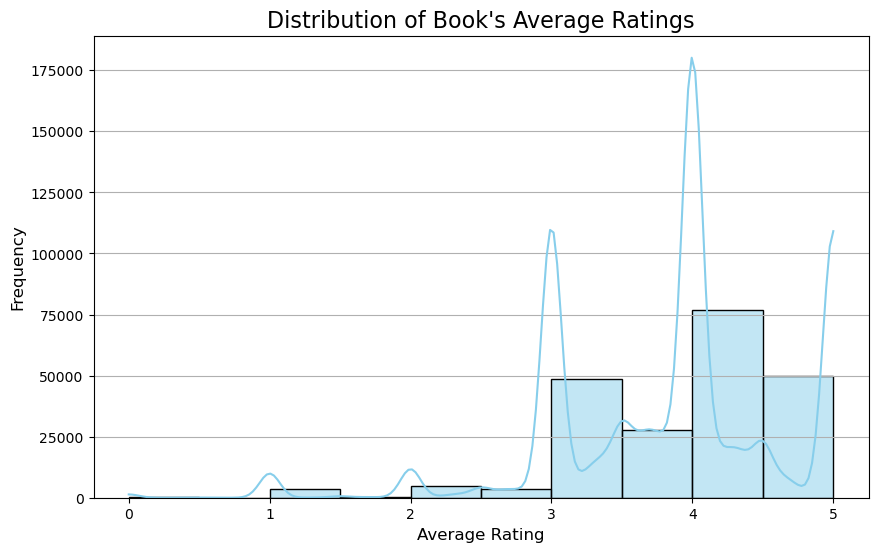

In [25]:
# preprocess the ratings to calculate the average rating per book
average_ratings = ratings_df.groupby("isbn13")["rating_score"].mean().reset_index()
average_ratings.columns = ["isbn13", "avg_rating"]

# Distribution of book's average rating by range
plt.figure(figsize=(10, 6))
sns.histplot(average_ratings["avg_rating"], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Book's Average Ratings", fontsize=16)
plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y')
plt.show()

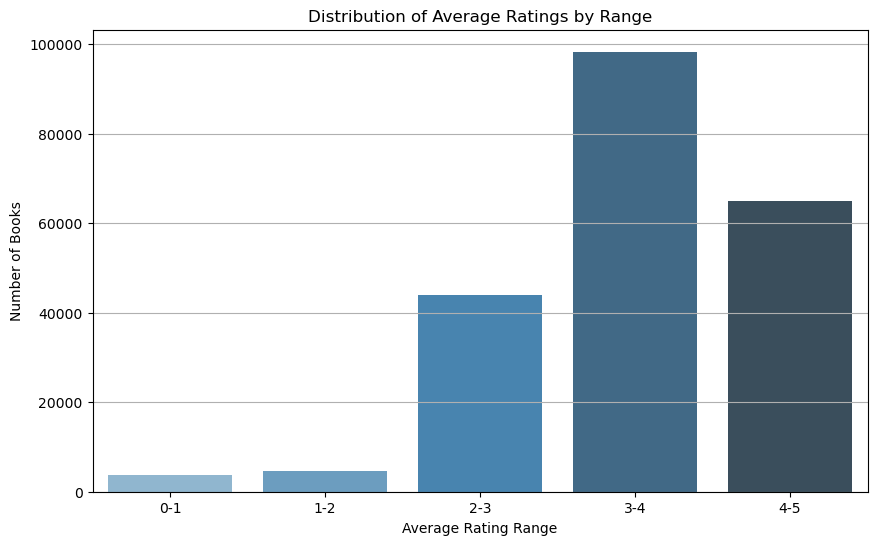

In [33]:
# Create bins for average rating ranges
rating_bins = pd.cut(average_ratings['avg_rating'], bins=[0, 1, 2, 3, 4, 5], labels=['0-1', '1-2', '2-3', '3-4', '4-5'])

# Count the number of books in each bin
rating_range_counts = rating_bins.value_counts().sort_index()

# Plot the grouped data as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_range_counts.index, y=rating_range_counts.values, palette='Blues_d')
plt.title('Distribution of Average Ratings by Range')
plt.xlabel('Average Rating Range')
plt.ylabel('Number of Books')
plt.grid(axis='y')
plt.show()

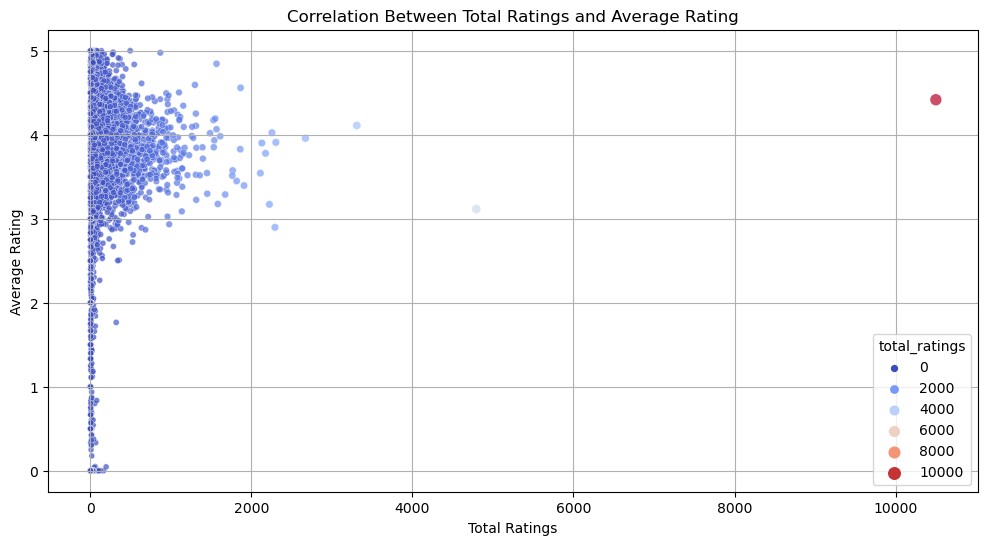

In [34]:
# Correlation of user's total ratings vs average rating
user_ratings_count = ratings_df.groupby("new_user_id")["isbn13"].count().reset_index()
user_ratings_count.columns = ["new_user_id", "total_ratings"]

# merge user total ratings with ratings to get user-wise average rating
user_avg_ratings = ratings_df.groupby("new_user_id")["rating_score"].mean().reset_index()
user_avg_ratings.columns = ["new_user_id", "avg_rating"]

data = pd.merge(user_ratings_count, user_avg_ratings, on="new_user_id")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x="total_ratings", y="avg_rating", alpha=0.7, hue='total_ratings', size='total_ratings', palette='coolwarm')
plt.title("Correlation Between Total Ratings and Average Rating")
plt.xlabel("Total Ratings")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()


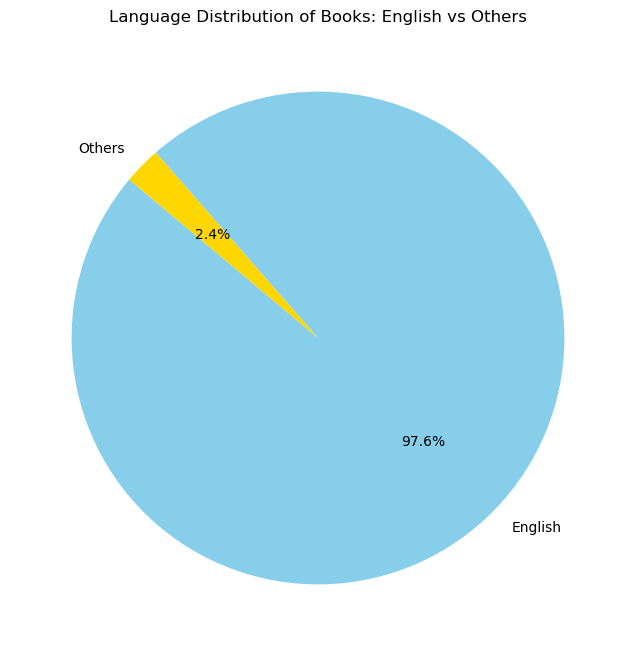

Exact Language Statistics:
English                                  97.5541%
Spanish; Castilian                        0.9253%
French                                    0.4995%
German                                    0.3528%
Italian                                   0.2078%
Thai                                      0.1100%
Greek, Modern (1453-)                     0.0489%
Persian                                   0.0403%
Russian                                   0.0302%
Japanese                                  0.0244%
Portuguese                                0.0224%
Dutch; Flemish                            0.0212%
Arabic                                    0.0163%
Multiple languages                        0.0155%
Swedish                                   0.0134%
Norwegian                                 0.0118%
Turkish                                   0.0081%
Ukrainian                                 0.0073%
Finnish                                   0.0069%
Polish                 

In [62]:
# language distribution
language_distribution = books_df['language'].value_counts(normalize=True) * 100
others_percentage = language_distribution.loc[language_distribution.index != 'English'].sum()
english_and_others = pd.Series({"English": language_distribution.get("English", 0), "Others": others_percentage})
plt.figure(figsize=(8, 8))
english_and_others.plot.pie(autopct="%1.1f%%", startangle=140, colors=[
        'skyblue', 'gold', 'orchid', 'green'])
plt.title("Language Distribution of Books: English vs Others")
plt.ylabel('')
plt.show()

# Print exact statistics for all languages
print("Exact Language Statistics:")
print(language_distribution.map("{:.4f}%".format))

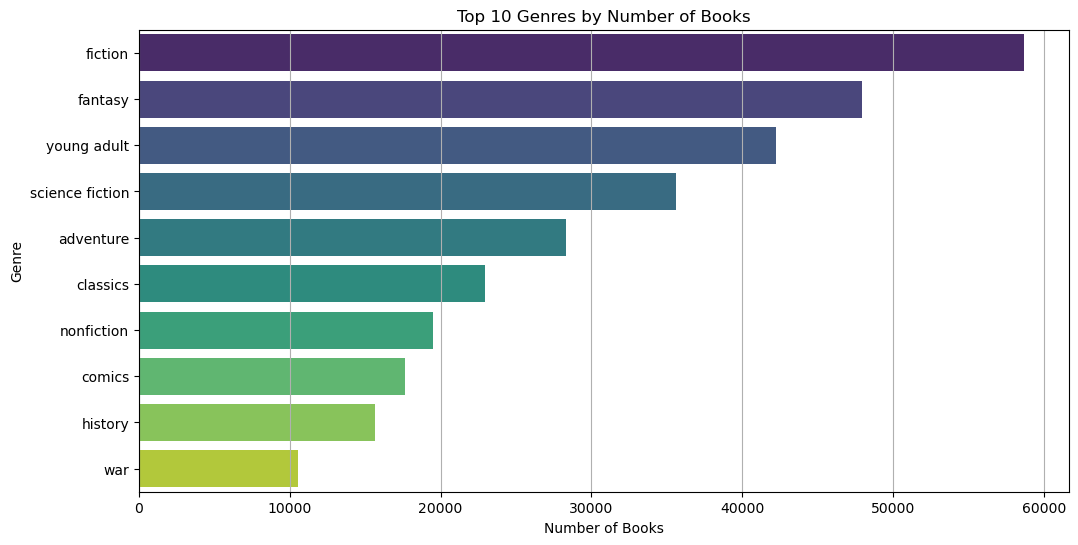

In [89]:
# Top 10 Genres by Number of Books
books_with_genres = pd.merge(books_df, books_genres_df, left_on="id", right_on="isbn13")
books_with_genres['genre_name'] = books_with_genres['genre_name'].str.lower()
genre_book_count = books_with_genres.groupby("genre_name")["id"].count().reset_index()
genre_book_count.columns = ["genre", "book_count"]
top_genres_by_books = genre_book_count.sort_values(by="book_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres_by_books, x="book_count", y="genre", palette="viridis")
plt.title("Top 10 Genres by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.grid(axis='x')
plt.show()



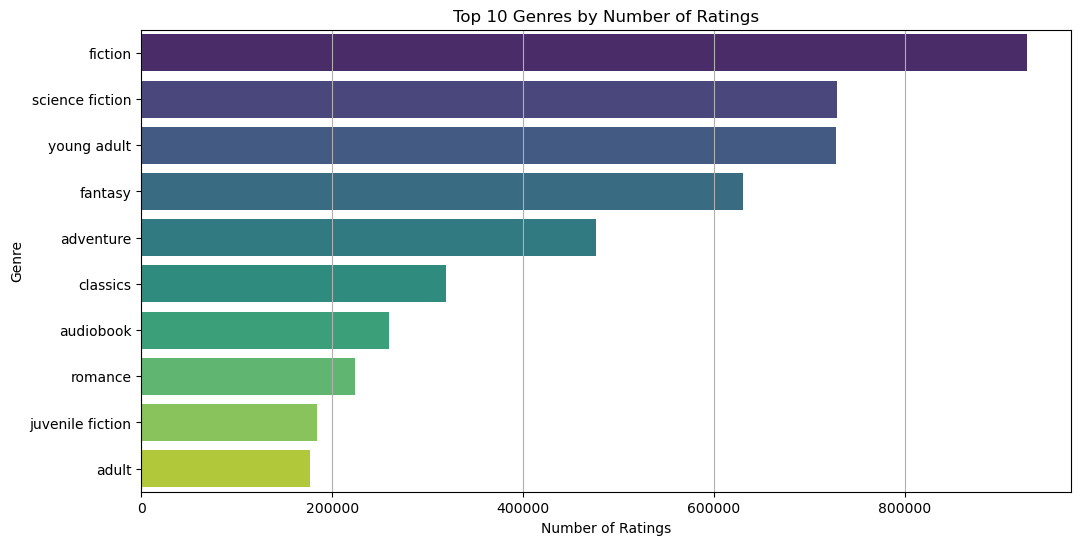

In [92]:
# 3. Top Genres by Number of Ratings
# Merge ratings with book_genres
books_ratings_genres = ratings_df.merge(books_genres_df, left_on='isbn13', right_on='isbn13', how='inner')
books_ratings_genres['genre_name'] = books_ratings_genres['genre_name'].str.lower()
genre_rating_count = books_ratings_genres.groupby("genre_name")['isbn13'].count().reset_index()
genre_rating_count.columns = ["genre", "rating_count"]
top_genres_ratings = genre_rating_count.sort_values(by="rating_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres_ratings, x="rating_count", y="genre", palette="viridis")
plt.title("Top 10 Genres by Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")
plt.grid(axis='x')
plt.show()

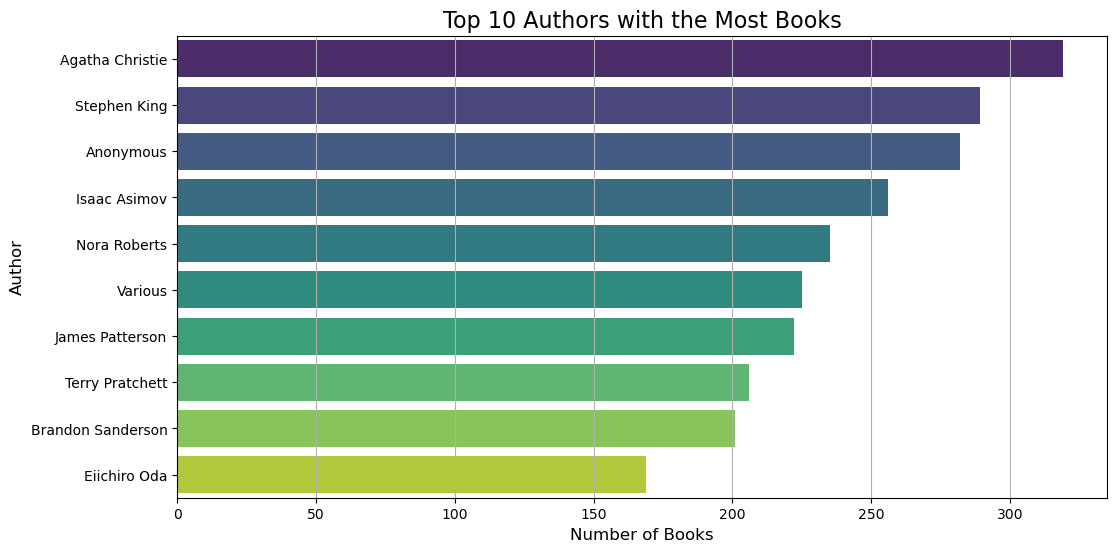

In [77]:
# top authors with the most books
books_per_author = books_df.groupby("author")["id"].count().reset_index()
books_per_author.columns = ["author", "book_count"]
books_per_author = books_per_author.sort_values(by="book_count", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=books_per_author, x="book_count", y="author", palette="viridis")
plt.title("Top 10 Authors with the Most Books", fontsize=16)
plt.xlabel("Number of Books", fontsize=12)
plt.ylabel("Author", fontsize=12)
plt.grid(axis='x')
plt.show()


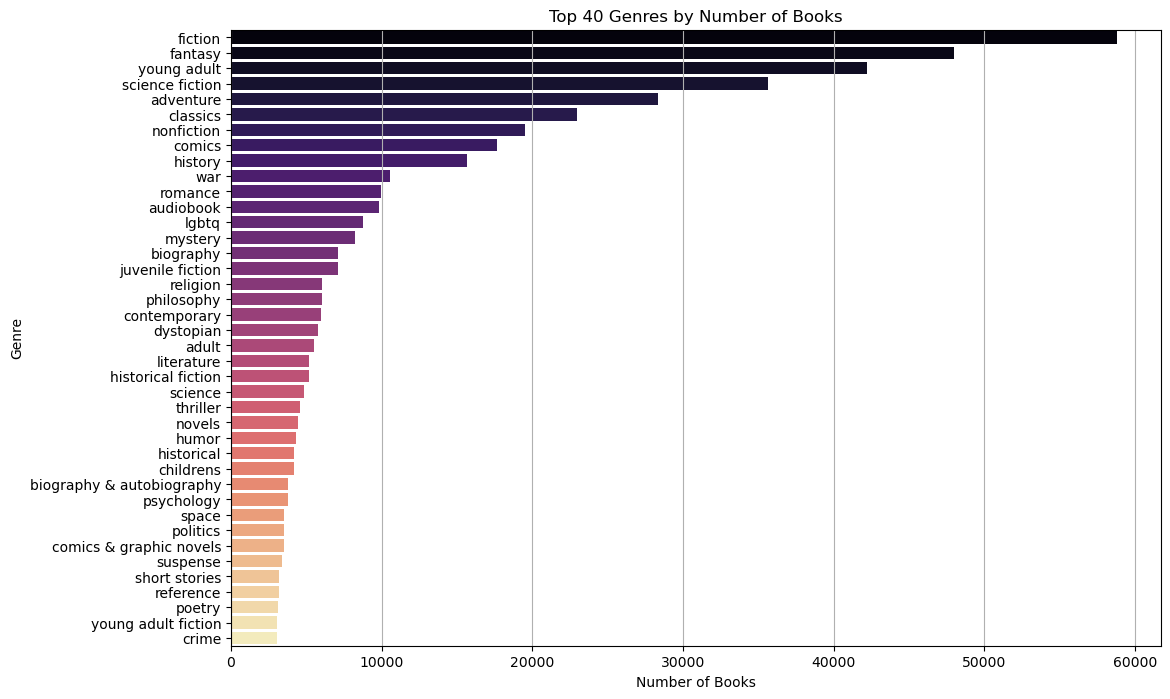

Exact count for each genre:
fiction                        58774
fantasy                        47973
young adult                    42220
science fiction                35624
adventure                      28354
                               ...  
self-disclosure                    1
nursing students                   1
andy (fictitious character)        1
marmots                            1
creative teaching                  1
Name: genre_name, Length: 7542, dtype: int64


In [114]:
# Genre count distribution
genre_counts = books_genres_df['genre_name'].str.lower().value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values[:40], y=genre_counts.index[:40], palette="magma")
plt.title("Top 40 Genres by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.grid(axis='x')
plt.show()

print("Exact count for each genre:")
print(genre_counts)

In [108]:
# Count genres in specified ranges
genre_ranges = {
    "1-5 books": genre_counts[(genre_counts >= 1) & (genre_counts <= 5)].count(),
    "6-10 books": genre_counts[(genre_counts >= 6) & (genre_counts <= 10)].count(),
    "11-20 books": genre_counts[(genre_counts >= 11) & (genre_counts <= 20)].count(),
    "21-50 books": genre_counts[(genre_counts >= 21) & (genre_counts <= 50)].count(),
    "51-100 books": genre_counts[(genre_counts >= 51) & (genre_counts <= 100)].count(),
    "101-200 books": genre_counts[(genre_counts >= 101) & (genre_counts <= 200)].count(),
    "201-300 books": genre_counts[(genre_counts >= 201) & (genre_counts <= 300)].count(),
    "301-500 books": genre_counts[(genre_counts >= 301) & (genre_counts <= 500)].count(),
    "500+ books": genre_counts[(genre_counts > 500)].count()
}

print("Genre count ranges:")
for range_label, count in genre_ranges.items():
    print(f"{range_label}: {count}")


Genre count ranges:
1-5 books: 6080
6-10 books: 429
11-20 books: 273
21-50 books: 242
51-100 books: 123
101-200 books: 113
201-300 books: 59
301-500 books: 61
500+ books: 162


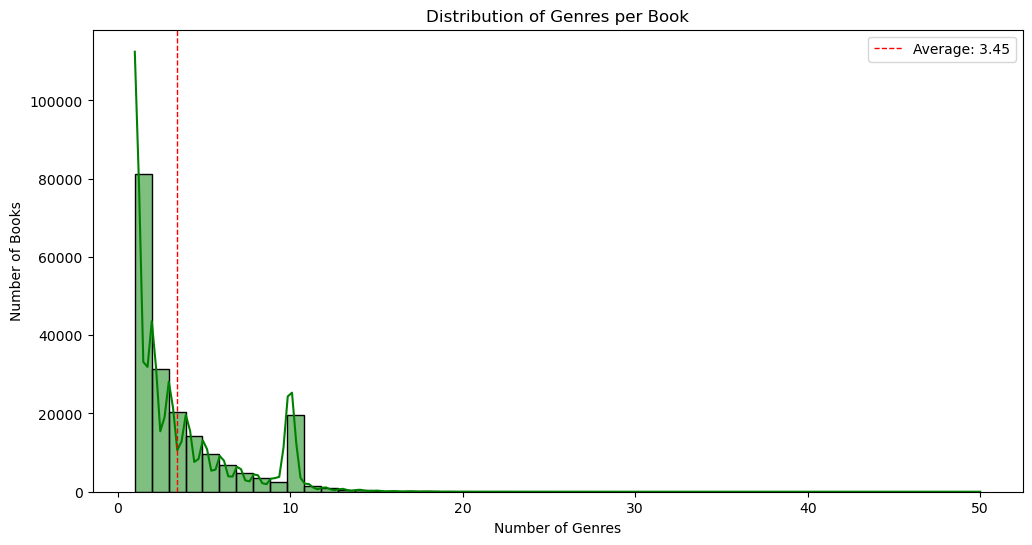

Average number of genres per book: 3.45


In [113]:
# Average number of genres vs actual distribution
# Calculate the number of genres per book
books_genre_count = books_genres_df.groupby('isbn13')['genre_name'].count()
average_genres = books_genre_count.mean()

plt.figure(figsize=(12, 6))
sns.histplot(books_genre_count, bins=50, kde=True, color='green')
plt.axvline(average_genres, color='red', linestyle='dashed', linewidth=1, label=f'Average: {average_genres:.2f}')
plt.title("Distribution of Genres per Book")
plt.xlabel("Number of Genres")
plt.ylabel("Number of Books")
plt.legend()
plt.show()

print(f"Average number of genres per book: {average_genres:.2f}")


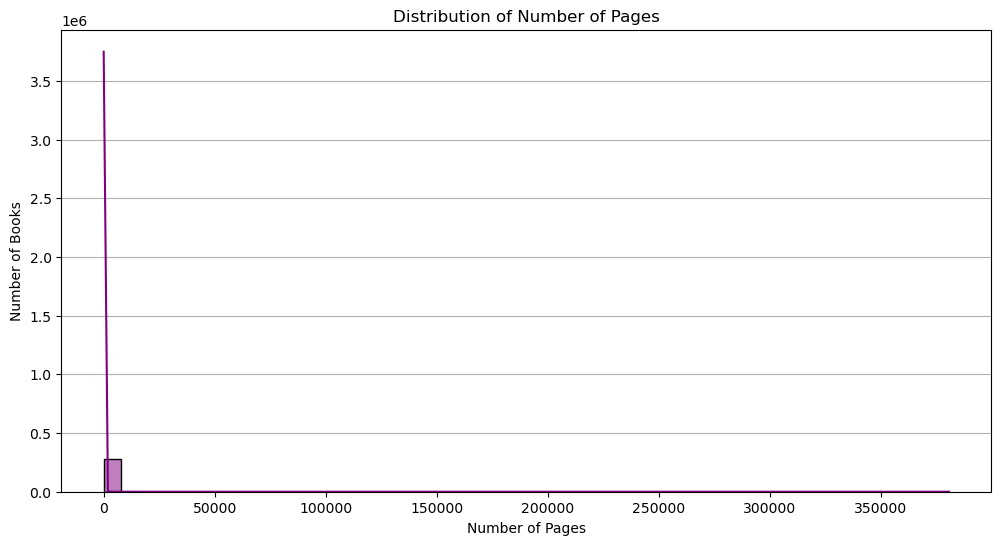

Number of Pages Statistics:
count    282224.00
mean        231.34
std         821.67
min           0.00
25%          43.00
50%         214.00
75%         336.00
max      380720.00
Name: num_pages, dtype: object


In [129]:
# Number of pages distribution
plt.figure(figsize=(12, 6))
sns.histplot(books_df['num_pages'].dropna(), bins=50, kde=True, color='purple')
plt.title("Distribution of Number of Pages")
plt.xlabel("Number of Pages")
plt.ylabel("Number of Books")
plt.grid(axis='y')
plt.show()

print("Number of Pages Statistics:")
print(books_df['num_pages'].describe().apply(lambda x: f"{x:.2f}"))

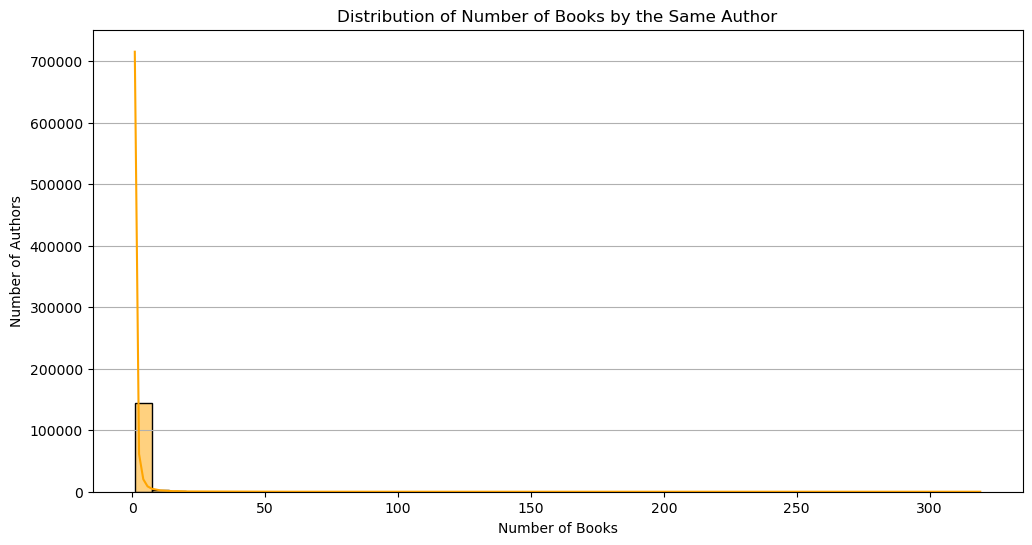

Number of Books by the Same Author:
count    149159.00
mean          1.90
std           4.41
min           1.00
25%           1.00
50%           1.00
75%           1.00
max         319.00
Name: author, dtype: object


In [127]:
# Number of books by the same author distribution
author_book_counts = books_df['author'].value_counts()
plt.figure(figsize=(12, 6))
sns.histplot(author_book_counts, bins=50, kde=True, color='orange')
plt.title("Distribution of Number of Books by the Same Author")
plt.xlabel("Number of Books")
plt.ylabel("Number of Authors")
plt.grid(axis='y')
plt.show()

print("Number of Books by the Same Author:")
print(author_book_counts.describe().apply(lambda x: f"{x:.2f}"))

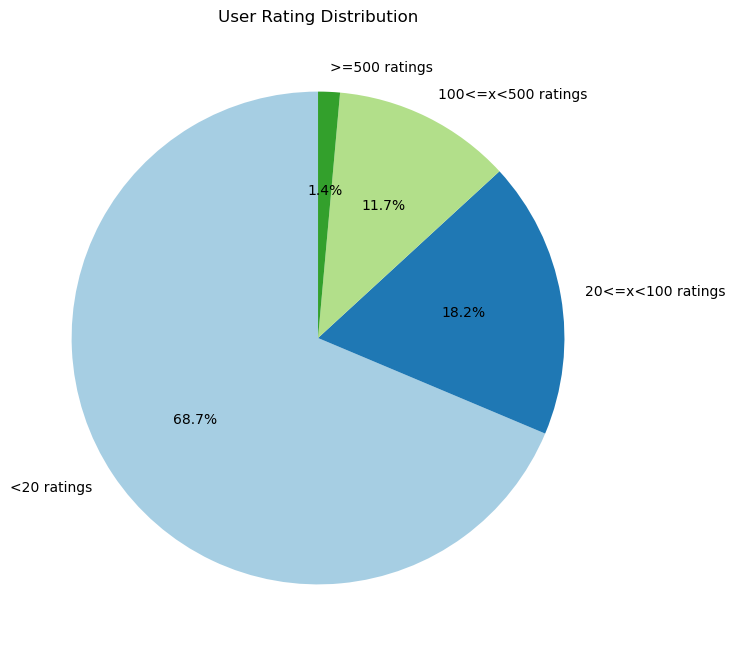

In [132]:
# group by user_id and count the number of ratings per user
user_rating_counts = ratings_df.groupby('new_user_id').size()

# Bin the user rating counts into categories
bins = [0, 20, 100, 500, float('inf')]
labels = ['<20 ratings', '20<=x<100 ratings', '100<=x<500 ratings', '>=500 ratings']
user_rating_categories = pd.cut(user_rating_counts, bins=bins, labels=labels, right=False)

# Count the number of users in each category
category_counts = user_rating_categories.value_counts(sort=False)

# Plot the pie chart
plt.figure(figsize=(8, 8))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('User Rating Distribution')
plt.ylabel('')  # Hide the y-label
plt.show()


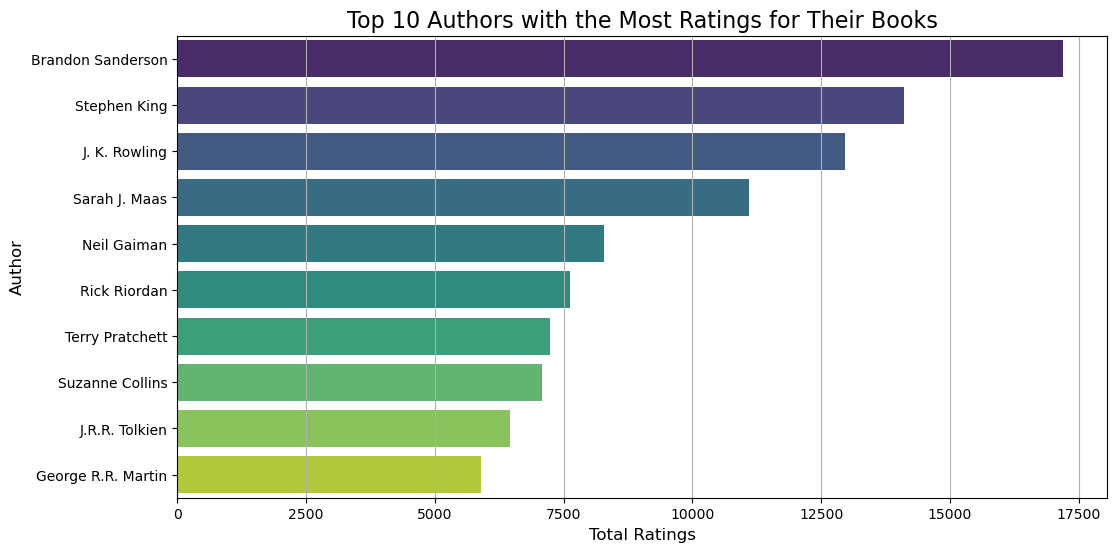

In [141]:
# Step 1: Aggregate the ratings per book
ratings_per_book = ratings_df.groupby("isbn13")["rating_score"].count().reset_index()
ratings_per_book.columns = ["isbn13", "ratings_count"]

# Step 2: Merge the ratings data with the books dataset to get the authors
books_with_ratings = pd.merge(books_df[['id', 'author']], ratings_per_book, left_on='id', right_on='isbn13', how='inner')

# Step 3: Aggregate ratings per author
ratings_per_author = books_with_ratings.groupby("author")["ratings_count"].sum().reset_index()

# Step 4: Sort authors by the total number of ratings and select top 10
ratings_per_author = ratings_per_author.sort_values(by="ratings_count", ascending=False).head(10)

# Step 5: Visualize the result using a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=ratings_per_author, x="ratings_count", y="author", palette="viridis")
plt.title("Top 10 Authors with the Most Ratings for Their Books", fontsize=16)
plt.xlabel("Total Ratings", fontsize=12)
plt.ylabel("Author", fontsize=12)
plt.grid(axis='x')
plt.show()
